<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/Dairy/CowsAnomalyDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install torch torchvision pytorchvideo decord



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 16.3 MB/s eta 0:00:00
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=72d3a59689d4e170bc12d8cbf716e6fe7869ff444f4158aa43810486633e7767
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=3b2dbfffe0bdb9c60f6e6a409eebdcb18e40bdc79f10601f7ee164f2bdcb5ec0
  Stored in directory: /root/.cache/pip/wheel

In [2]:
!pip install opencv-python tqdm pandas

In [3]:
!pip install kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download("fandaoerji/cbvd-5cow-behavior-video-dataset")
print(path)
import os

for d in os.listdir(path):
    print(d)

100%|██████████| 10.8G/10.8G [01:01<00:00, 189MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11
annotations
minilabelframes
CBVD-5.csv
videos
rawframes_mini
miniannotations
labelframes
labelframes_add
videos_add


In [5]:
import os


print("Dataset root path:", path)


print("\nDataset structure preview:")
for root, dirs, files in os.walk(path):
    if files:
        rel = os.path.relpath(root, path)
        print(f"{rel}/  → {len(files)} files (first 3: {files[:3]})")


DATA_ROOT = path
ANNOTATIONS_DIR = os.path.join(path, "annotations")
VIDEO_DIR = os.path.join(path, "video_cut")
RAWFRAMES_DIR = os.path.join(path, "rawframes")

print(f"\n Paths ready:")
print(f"   DATA_ROOT       = {DATA_ROOT}")
print(f"   ANNOTATIONS_DIR = {ANNOTATIONS_DIR}")
print(f"   VIDEO_DIR       = {VIDEO_DIR}")

Dataset root path: /root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11

Dataset structure preview:
./  → 1 files (first 3: ['CBVD-5.csv'])
annotations/  → 11 files (first 3: ['ava_val_v2.1.csv', 'ava_test_excluded_timestamps_v2.1.csv', 'ava_action_list_v2.1_for_activitynet_2018.pbtxt'])
minilabelframes/  → 4122 files (first 3: ['154_00006.jpg', '316_00006.jpg', '241_00007.jpg'])
videos/videos/  → 687 files (first 3: ['42.mp4', '605.mp4', '415.mp4'])
rawframes_mini/68/  → 300 files (first 3: ['img_00191.jpg', 'img_00250.jpg', 'img_00108.jpg'])
rawframes_mini/637/  → 300 files (first 3: ['img_00191.jpg', 'img_00250.jpg', 'img_00108.jpg'])
rawframes_mini/522/  → 300 files (first 3: ['img_00191.jpg', 'img_00250.jpg', 'img_00108.jpg'])
rawframes_mini/547/  → 300 files (first 3: ['img_00191.jpg', 'img_00250.jpg', 'img_00108.jpg'])
rawframes_mini/687/  → 300 files (first 3: ['img_00191.jpg', 'img_00250.jpg', 'img_00108.jpg'])
rawframes_mini/537/  → 300 file

In [6]:
DATA_ROOT = path

ANNOTATIONS_DIR = os.path.join(DATA_ROOT, "miniannotations")
FRAMES_DIR = os.path.join(DATA_ROOT, "rawframes_mini")

print(os.listdir(ANNOTATIONS_DIR))
ann_file = None

for f in os.listdir(ANNOTATIONS_DIR):
    if f.endswith(".csv"):
        ann_file = os.path.join(ANNOTATIONS_DIR, f)
        break

print("Using:", ann_file)

['ava_val_v2.1.csv', 'ava_test_excluded_timestamps_v2.1.csv', 'ava_action_list_v2.1_for_activitynet_2018.pbtxt', 'ava_dense_proposals_train.FAIR.recall_93.9.pkl', 'ava_train_excluded_timestamps_v2.1.csv', 'labelmap.txt', 'ava_dense_proposals_test.FAIR.recall_93.9.pkl', 'ava_val_excluded_timestamps_v2.1.csv', 'ava_train_v2.1.csv', 'ava_dense_proposals_val.FAIR.recall_93.9.pkl', 'ava_test_v2.1.csv']
Using: /root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/miniannotations/ava_val_v2.1.csv


In [7]:
import pandas as pd

df = pd.read_csv(ann_file, header=None, dtype={0: str})

df.columns = [
    "video_id",
    "timestamp",
    "x1", "y1", "x2", "y2",
    "action_id",
    "target_id"
]

print(df.head())
print("Total samples:", len(df))

  video_id  timestamp        x1        y1        x2        y2  action_id  \
0      393          4  0.328125  0.226562  0.414062  0.359375          2   
1      393          4  0.328125  0.226562  0.414062  0.359375          5   
2      393          4  0.304688  0.199219  0.378906  0.296875          2   
3      393          4  0.304688  0.199219  0.378906  0.296875          5   
4      393          4  0.218750  0.218750  0.304688  0.292969          2   

   target_id  
0          1  
1          1  
2          1  
3          1  
4          1  
Total samples: 3761


In [8]:
import os

print("Sample frame folders:")
print(os.listdir(FRAMES_DIR)[:20])
print("Sample video_ids from annotations:")
print(df["video_id"].head(20).tolist())

Sample frame folders:
['68', '637', '522', '547', '687', '537', '141', '318', '495', '420', '123', '511', '364', '91', '195', '433', '142', '29', '548', '45']
Sample video_ids from annotations:
['393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393', '393']


In [9]:
valid_ids = set(os.listdir(FRAMES_DIR))

print("Number of frame folders:", len(valid_ids))

Number of frame folders: 686


In [10]:
df["video_id"] = df["video_id"].apply(lambda x: str(int(x)))

df = df[df["video_id"].isin(valid_ids)]

print("Filtered dataset size:", len(df))

Filtered dataset size: 3761


Video dir exists: False


In [11]:
import torch
from torch.utils.data import Dataset
import os
import cv2

class CowFrameDataset(Dataset):
    def __init__(self, df, frames_dir, num_frames=8):
        self.df = df.reset_index(drop=True)
        self.frames_dir = frames_dir
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        video_folder = os.path.join(self.frames_dir, row.video_id)

        frame_files = sorted(os.listdir(video_folder))

        # pick center frame
        center_idx = len(frame_files) // 2
        start = max(0, center_idx - self.num_frames // 2)

        selected = frame_files[start:start+self.num_frames]

        frames = []
        for f in selected:
            img_path = os.path.join(video_folder, f)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (112, 112))
            img = img / 255.0
            frames.append(img)

        if len(frames) == 0:
            frames = [torch.zeros(112,112,3).numpy()] * self.num_frames

        frames = torch.tensor(frames).permute(0,3,1,2).float()

        label = int(row.action_id) - 1
        return frames, label

In [12]:
import torch.nn as nn

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)
        x = self.conv(x)
        return self.fc(x)

In [13]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

In [14]:
from torch.utils.data import random_split, DataLoader

dataset = CowFrameDataset(df.sample(3000), FRAMES_DIR)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [15]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Simple3DCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 5

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for frames, labels in train_loader:
        frames, labels = frames.to(device), labels.to(device)

        preds = model(frames)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(preds, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)

            preds = model(frames)
            loss = criterion(preds, labels)

            val_loss += loss.item()

            _, predicted = torch.max(preds, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    print("-" * 40)

/tmp/ipykernel_2348/3633324586.py:43: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  frames = torch.tensor(frames).permute(0,3,1,2).float()


Epoch 1/5
Train Loss: 1.2578, Train Acc: 0.4817
Val   Loss: 1.2822, Val   Acc: 0.4767
----------------------------------------
Epoch 2/5
Train Loss: 1.1980, Train Acc: 0.5017
Val   Loss: 1.2273, Val   Acc: 0.4833
----------------------------------------
Epoch 3/5
Train Loss: 1.1649, Train Acc: 0.5050
Val   Loss: 1.2051, Val   Acc: 0.4850
----------------------------------------
Epoch 4/5
Train Loss: 1.1495, Train Acc: 0.5088
Val   Loss: 1.2005, Val   Acc: 0.4850
----------------------------------------
Epoch 5/5
Train Loss: 1.1338, Train Acc: 0.5146
Val   Loss: 1.2039, Val   Acc: 0.4767
----------------------------------------


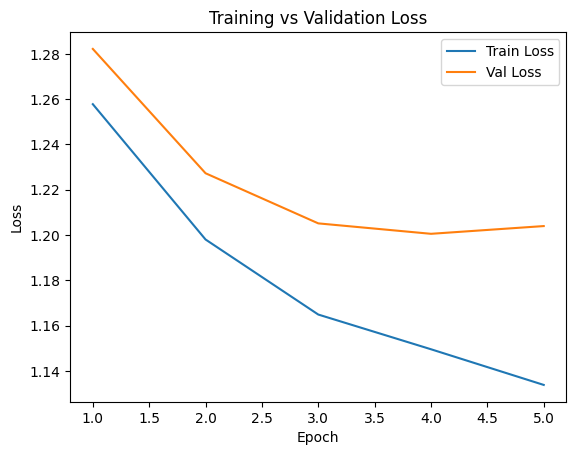

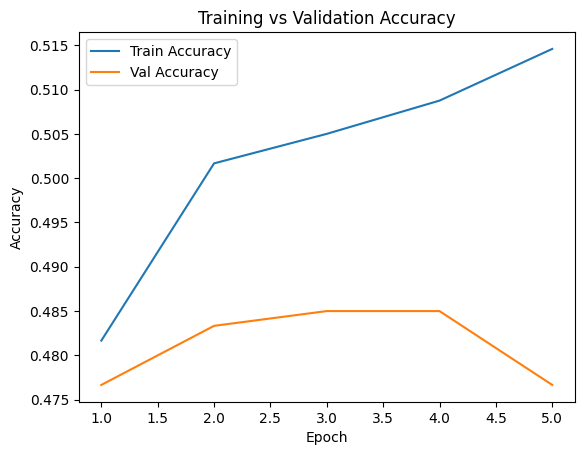

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()